# Linear Regression: How It Works

This notebook introduces linear regression with small datasets from `scikit-learn`.

We will cover:

- what a linear regression model learns;
- how to fit and evaluate it on the diabetes regression dataset;
- how residuals show model mistakes;
- how underfitting and overfitting look visually;
- why adding more data usually does not fix underfitting, but can reduce overfitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (9, 5),
})

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. The Basic Idea

For one input feature, linear regression learns a line:

$$\hat{y} = b_0 + b_1x$$

For several input features, it learns one coefficient per feature:

$$\hat{y} = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

The model chooses the coefficients that make predictions close to the real targets, usually by minimizing squared residuals.

A residual is:

$$\text{residual} = y - \hat{y}$$

## 2. Load a Regression Dataset

`load_diabetes` is a small numeric regression dataset bundled with `scikit-learn`. The target is a quantitative measure of disease progression one year after baseline.

In [2]:
diabetes = load_diabetes(as_frame=True)
diabetes_df: pd.DataFrame = diabetes.frame

diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print(f"Rows: {diabetes_df.shape[0]}")
print(f"Input features: {diabetes.data.shape[1]}")
print(f"Feature names: {diabetes.feature_names}")

Rows: 442
Input features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 3. Simple Linear Regression with One Feature

We start with one feature, `bmi`, because it has a visible relationship with the target and gives us a line that is easy to plot.

In [4]:
X = diabetes_df[["bmi"]]
y = diabetes_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

intercept = simple_model.intercept_
slope = simple_model.coef_[0]

print(f"Learned equation: target = {intercept:.2f} + {slope:.2f} * bmi")

Learned equation: target = 152.08 + 975.28 * bmi


In [5]:
def regression_report(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return pd.DataFrame(
        {
            "MAE": [
                mean_absolute_error(y_train, train_pred),
                mean_absolute_error(y_test, test_pred),
            ],
            "RMSE": [
                np.sqrt(mean_squared_error(y_train, train_pred)),
                np.sqrt(mean_squared_error(y_test, test_pred)),
            ],
            "R2": [
                r2_score(y_train, train_pred),
                r2_score(y_test, test_pred),
            ],
        },
        index=["train", "test"],
    ).round(3)

regression_report(simple_model, X_train, y_train, X_test, y_test)

,MAE,RMSE,R2
train,52.288,62.698,0.350
test,49.805,61.446,0.317


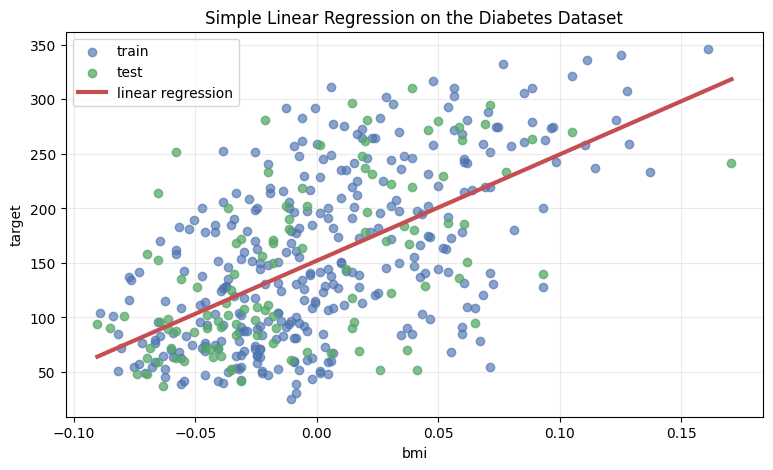

In [6]:
x_grid = np.linspace(X["bmi"].min(), X["bmi"].max(), 200)
y_grid = simple_model.predict(pd.DataFrame({"bmi": x_grid}))

plt.scatter(X_train["bmi"], y_train, alpha=0.65, label="train", color="#4C72B0")
plt.scatter(X_test["bmi"], y_test, alpha=0.75, label="test", color="#55A868")
plt.plot(x_grid, y_grid, color="#C44E52", linewidth=3, label="linear regression")

plt.title("Simple Linear Regression on the Diabetes Dataset")
plt.xlabel("bmi")
plt.ylabel("target")
plt.legend()
plt.show()

## 4. Residuals: The Mistakes the Model Minimizes

The vertical distance from each point to the fitted line is the residual. Linear regression chooses the line that minimizes the sum of squared residuals on the training data.

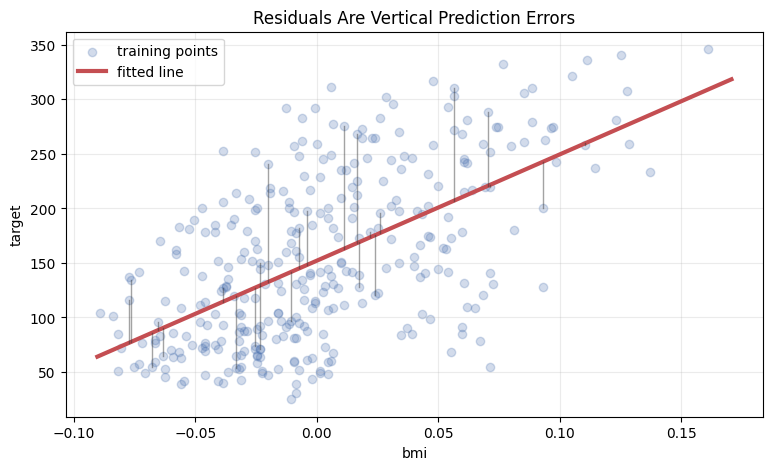

In [7]:
residual_sample = X_train.copy()
residual_sample["actual"] = y_train
residual_sample["predicted"] = simple_model.predict(X_train)
residual_sample = residual_sample.sample(25, random_state=RANDOM_STATE).sort_values("bmi")

plt.scatter(X_train["bmi"], y_train, alpha=0.25, color="#4C72B0", label="training points")
plt.plot(x_grid, y_grid, color="#C44E52", linewidth=3, label="fitted line")

for _, row in residual_sample.iterrows():
    plt.plot(
        [row["bmi"], row["bmi"]],
        [row["actual"], row["predicted"]],
        color="#333333",
        alpha=0.45,
        linewidth=1,
    )

plt.title("Residuals Are Vertical Prediction Errors")
plt.xlabel("bmi")
plt.ylabel("target")
plt.legend()
plt.show()

## 5. Multiple Linear Regression

With multiple linear regression, the model still learns a linear equation, but it uses all available features instead of only `bmi`.

In [8]:
X_all = diabetes_df.drop(columns="target")
y_all = diabetes_df["target"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

multi_model = LinearRegression()
multi_model.fit(X_train_all, y_train_all)

single_feature_metrics = regression_report(simple_model, X_train, y_train, X_test, y_test).loc["test"]
all_feature_metrics = regression_report(multi_model, X_train_all, y_train_all, X_test_all, y_test_all).loc["test"]

pd.DataFrame(
    [single_feature_metrics, all_feature_metrics],
    index=["one feature: bmi", "all diabetes features"],
).round(3)

,MAE,RMSE,R2
one feature: bmi,49.805,61.446,0.317
all diabetes features,41.549,53.370,0.485


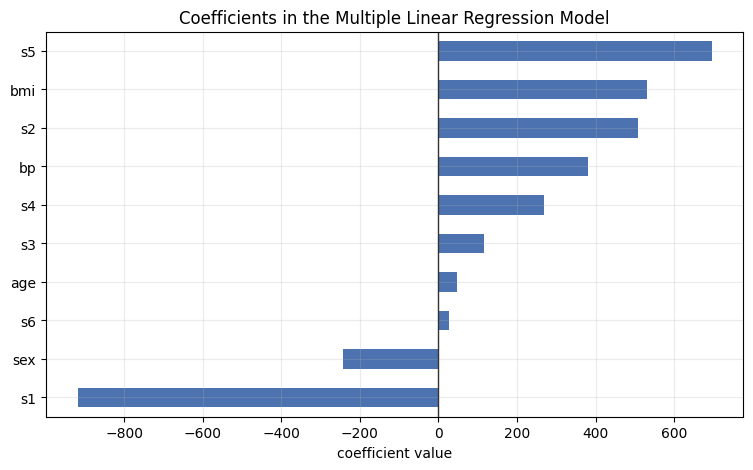

In [9]:
coefficients = pd.Series(multi_model.coef_, index=X_all.columns).sort_values()

ax = coefficients.plot(kind="barh", color="#4C72B0")
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Coefficients in the Multiple Linear Regression Model")
ax.set_xlabel("coefficient value")
plt.show()

## 6. Underfitting and Overfitting

Linear regression is not only one straight line. It can also be combined with feature transformations.

For example, polynomial regression still uses `LinearRegression`, but it first creates transformed features:

$$x, x^2, x^3, \dots$$

Then linear regression learns coefficients for those transformed features.

This lets us demonstrate three model behaviors:

- **Underfitting:** the model is too simple and misses the real pattern.
- **Good fit:** the model captures the main pattern without following noise.
- **Overfitting:** the model is too flexible and follows random noise in the training data.

In [10]:
# We use sklearn to create a simple one-feature sample, then add a known nonlinear target.
# This gives us a controlled teaching example where the true pattern can be plotted.
X_source, _ = make_regression(
    n_samples=240,
    n_features=1,
    noise=0.0,
    random_state=RANDOM_STATE,
)

x = X_source[:, 0]

# Keep extreme values from dominating polynomial extrapolation, then map to a readable range.
lo, hi = np.percentile(x, [2, 98])
x = np.clip(x, lo, hi)
x = 6 * (x - x.min()) / (x.max() - x.min()) - 3


def true_function(x_values):
    return 25 * np.sin(1.35 * x_values) + 7 * x_values


y = true_function(x) + rng.normal(scale=6.0, size=x.shape)
X_curve = x.reshape(-1, 1)

X_pool, X_holdout, y_pool, y_holdout = train_test_split(
    X_curve,
    y,
    test_size=0.45,
    random_state=RANDOM_STATE,
)

small_idx = rng.choice(len(X_pool), size=18, replace=False)
X_small, y_small = X_pool[small_idx], y_pool[small_idx]
X_large, y_large = X_pool, y_pool

print(f"Small training set: {len(X_small)} examples")
print(f"Larger training set: {len(X_large)} examples")
print(f"Holdout test set: {len(X_holdout)} examples")

Small training set: 18 examples
Larger training set: 132 examples
Holdout test set: 108 examples


In [11]:
def polynomial_regression(degree):
    return make_pipeline(
        MinMaxScaler(feature_range=(-1, 1)),
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


training_sets = {
    "18 examples": (X_small, y_small),
    "132 examples": (X_large, y_large),
}

model_degrees = {
    "Underfit linear model": 1,
    "Reasonable polynomial model": 5,
    "Overfit polynomial model": 7,
}

rows = []
for training_label, (X_train_curve, y_train_curve) in training_sets.items():
    for model_label, degree in model_degrees.items():
        model = polynomial_regression(degree)
        model.fit(X_train_curve, y_train_curve)
        rows.append(
            {
                "training data": training_label,
                "model": model_label,
                "degree": degree,
                "train RMSE": rmse(y_train_curve, model.predict(X_train_curve)),
                "test RMSE": rmse(y_holdout, model.predict(X_holdout)),
            }
        )

metrics_df = pd.DataFrame(rows)
metrics_df.round(2)

,training data,model,degree,train RMSE,test RMSE
0,18 examples,Underfit linear model,1,15.13,18.50
1,18 examples,Reasonable polynomial model,5,3.06,26.56
2,18 examples,Overfit polynomial model,7,3.03,23.50
3,132 examples,Underfit linear model,1,16.67,17.59
4,132 examples,Reasonable polynomial model,5,4.97,5.81
5,132 examples,Overfit polynomial model,7,4.83,5.77


In [12]:
summary = metrics_df.pivot_table(
    index="model",
    columns="training data",
    values="test RMSE",
)
summary["test RMSE improvement from more data"] = summary["18 examples"] - summary["132 examples"]
summary.round(2)

training data,132 examples,18 examples,test RMSE improvement from more data
model,,,
Overfit polynomial model,5.77,23.50,17.73
Reasonable polynomial model,5.81,26.56,20.75
Underfit linear model,17.59,18.50,0.91


Read the table this way:

- If a model is underfitting, both small-data and larger-data test error stay high because the model class is too simple.
- If a model is overfitting, small-data test error is much worse than training error; adding more data can help because the flexible model has more evidence about the real pattern.

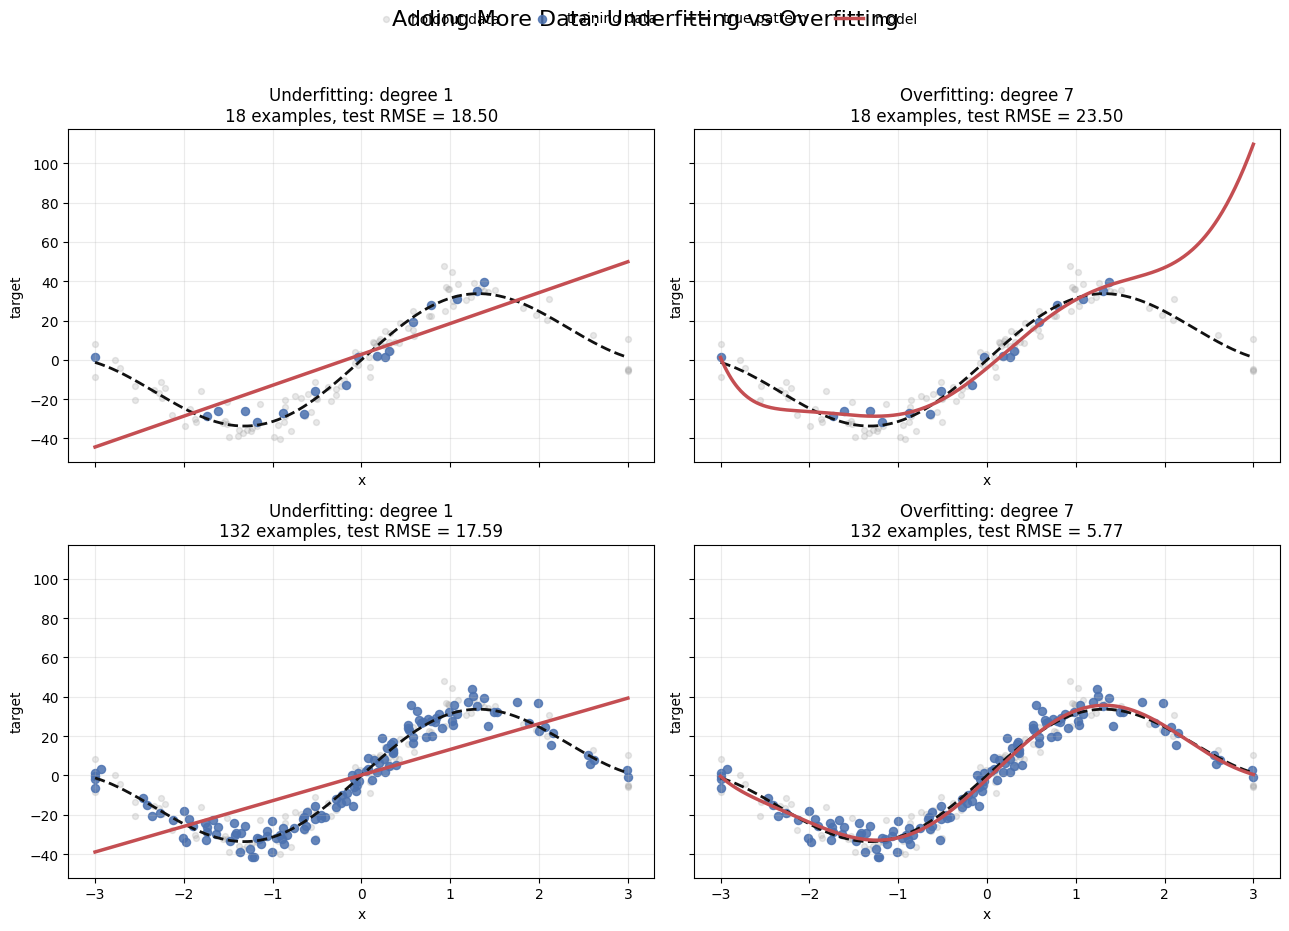

In [13]:
x_plot = np.linspace(X_curve.min(), X_curve.max(), 500).reshape(-1, 1)
y_true_plot = true_function(x_plot.ravel())

plot_configs = [
    ("18 examples", X_small, y_small),
    ("132 examples", X_large, y_large),
]
model_configs = [
    ("Underfitting: degree 1", 1),
    ("Overfitting: degree 7", 7),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for row_idx, (training_label, X_train_curve, y_train_curve) in enumerate(plot_configs):
    for col_idx, (model_label, degree) in enumerate(model_configs):
        ax = axes[row_idx, col_idx]
        model = polynomial_regression(degree)
        model.fit(X_train_curve, y_train_curve)
        y_plot = model.predict(x_plot)
        test_error = rmse(y_holdout, model.predict(X_holdout))

        ax.scatter(X_holdout[:, 0], y_holdout, s=18, alpha=0.22, color="#999999", label="holdout data")
        ax.scatter(X_train_curve[:, 0], y_train_curve, s=34, alpha=0.85, color="#4C72B0", label="training data")
        ax.plot(x_plot[:, 0], y_true_plot, color="#111111", linewidth=2, linestyle="--", label="true pattern")
        ax.plot(x_plot[:, 0], y_plot, color="#C44E52", linewidth=2.5, label="model")

        ax.set_title(f"{model_label}\n{training_label}, test RMSE = {test_error:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("target")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
fig.suptitle("Adding More Data: Underfitting vs Overfitting", y=1.03, fontsize=16)
fig.tight_layout()
plt.show()

## 7. Main Takeaways

1. Linear regression learns coefficients that minimize prediction errors on the training data.
2. A simple one-feature model is easy to visualize, but it may miss useful information.
3. Multiple linear regression uses more features while remaining linear in the coefficients.
4. Underfitting is a model-capacity problem: more data alone usually does not fix it.
5. Overfitting is often a data-versus-flexibility problem: more data can reduce it, but regularization and simpler models can also help.